In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve, auc
)
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.preprocessing import label_binarize

2026-05-09 08:55:12.580750: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778316912.845427      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778316912.926823      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778316913.593382      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778316913.593425      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778316913.593428      16 computation_placer.cc:177] computation placer alr

In [2]:
model = load_model("/kaggle/input/models/mistblade69/resnetmobilenet-mods/keras/default/1/resnet50_tumor_model.keras")

test_dir = r"/kaggle/input/datasets/mistblade69/brisc-dataset2025/brisc2025/classification_task/test"

2026-05-09 08:55:44.334575: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
test_datagen = ImageDataGenerator(preprocessing_function =preprocess_input)

In [4]:
test_dataset = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1000 images belonging to 4 classes.


In [5]:
y_pred_probs = model.predict(test_dataset)

y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true = test_dataset.classes

class_names = list(test_dataset.class_indices.keys())

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step


In [6]:
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

report_df.to_csv(
    "/kaggle/working/resnet_classification_report.csv",
    index=True
)

print("Classification report saved.")

              precision    recall  f1-score   support
glioma         0.959350  0.929134  0.944000   254.000
meningioma     0.970260  0.852941  0.907826   306.000
no_tumor       0.985816  0.992857  0.989324   140.000
pituitary      0.866279  0.993333  0.925466   300.000
accuracy       0.934000  0.934000  0.934000     0.934
macro avg      0.945426  0.942066  0.941654  1000.000
weighted avg   0.938472  0.934000  0.933716  1000.000
Classification report saved.


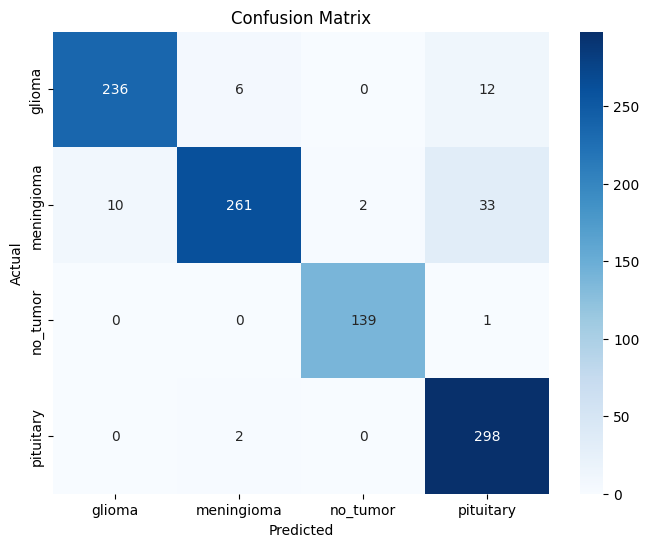

In [7]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    "/kaggle/working/resnet_confusion_matrix.png",
    bbox_inches='tight'
)

plt.show()

In [8]:
y_true_bin = label_binarize(
    y_true,
    classes=np.unique(y_true)
)

auc_score = roc_auc_score(
    y_true_bin,
    y_pred_probs,
    multi_class='ovr'
)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.995279959401383


In [9]:
n_classes = y_true_bin.shape[1]

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(
        y_true_bin[:, i],
        y_pred_probs[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

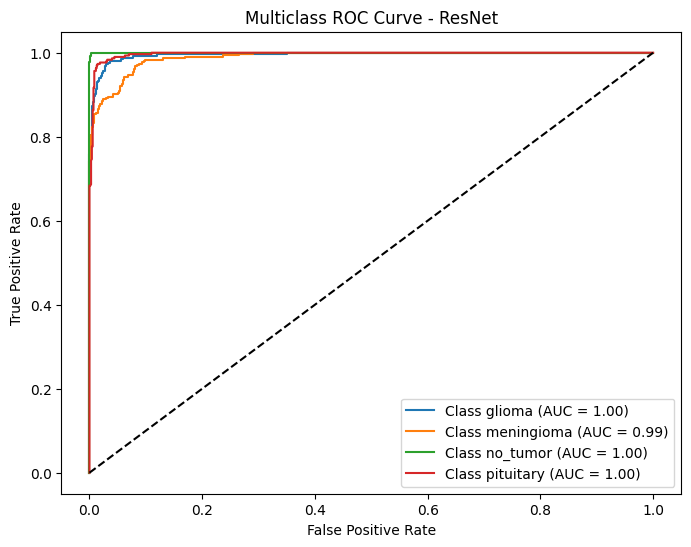

In [10]:
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Multiclass ROC Curve - ResNet')

plt.legend(loc='lower right')

plt.savefig(
    "/kaggle/working/resnet_roc_curve.png",
    bbox_inches='tight'
)

plt.show()

In [11]:
print("Total Parameters:", model.count_params())

Total Parameters: 24121476


In [12]:
start = time.time()

model.predict(test_dataset)

end = time.time()

total_time = end - start

print("Total Inference Time:", total_time)

print(
    "Average Per Image:",
    total_time / len(test_dataset.filenames)
)

32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step
Total Inference Time: 89.73476243019104
Average Per Image: 0.08973476243019105
